In [4]:
# imports:
from rosbags.rosbag2 import Reader  # this is actually a MARV library
from rosbags.serde import deserialize_cdr
from rosbags.typesys import Stores, get_typestore, get_types_from_msg, TypesysError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import plotly.express as px
from bitstring import BitArray
import os
import math

In [5]:
# global settings:
path="./"  # for saving plots
#rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/DIN_SAE_SPEC/Scenario_3/Higher_Distance/3-5m_diff_HAP_POI_1_2025-09-26_10-17-17/"
#rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/DIN_SAE_SPEC/Scenario_3/Higher_Distance/3m_diff_HAP_POI_1_2025-09-26_10-15-54/"
#rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/DIN_SAE_SPEC/Scenario_3/Higher_Distance/4-5m_diff_HAP_POI_1_2025-09-26_10-19-25/"
#rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/DIN_SAE_SPEC/Scenario_3/Higher_Distance/4m_diff_HAP_POI_1_2025-09-26_10-18-12/"
rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/DIN_SAE_SPEC/Scenario_3/Higher_Distance/5m_diff_HAP_POI_1_2025-09-26_10-20-32/"

#rosbag_dir = "/media/markus/Extreme_SSD/rosbags/Livox_HAP_driver_investigation/config_with_non_repetivitve_pattern/altered_driver/rosbag2_2025_08_29-16_27_41"
#rosbag_dir = "/media/markus/Extreme_SSD/rosbags/Livox_HAP_driver_investigation/config_with_non_repetivitve_pattern/original_driver/rosbag2_2025_08_29-16_43_53"
#rosbag_dir = "/media/markus/Extreme_SSD/rosbags/Livox_HAP_driver_investigation/config_with_fixed_pattern/rosbag2_2025_08_28-18_09_41"
#rosbag_dir = "/media/markus/Extreme_SSD/rosbags/Livox_HAP_driver_investigation/config_with_permanent_time_sync/rosbag2_2025_08_29-08_21_50"
#rosbag_dir = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/Livox_HAP_TX/2025-08-18T14-09-58Z/"

#topic = "/ods/l_06_c_c/pointcloud" # on dmu
topic = "/ods/l_02_c_c/pointcloud"  # DIN SAE SPEC 91471 measurements
#topic = "/livox/lidar_192_168_43_117"  # this topic has PoinCloud2 message format, but custom pointfield"
#topic = "/livox/lidar"  # topic in the rosbag recorded with the original driver

typestore = get_typestore(Stores.ROS2_HUMBLE)

In [26]:
def interpret_point_flags(df: pd.DataFrame, col: str, little_endianness: bool = True):
    """
    # NOTE: This function does not quite work as intented, use instead the version with the bitshift below!

    Read the livox_tag bits
    """

    ''' manual: the messages are serialized using little-endian encoding '''
    
    names = ["spatial_noise", "intensity_noise", "return_idx", "reserved"]
    bits = [2,2,2,2]  # this is the encoding found in Table on page 15 of the manual
    for row in range(len(df)):
        if little_endianness:
            #print(row, col)
            le = BitArray(uintle=df.loc[row, col], length=8)
            j = 0
            for i in range(len(names)):
                df.loc[row, names[i]] = le[j:j+bits[i]].uint
                j += bits[i]
        else:    
            be = BitArray(uintbe=df.loc[row, col], length=8)
            j = 0
            for i in range(len(names)):
                df.loc[row, names[i]] = be[j:j+bits[i]].uint
                j += bits[i]

def interpret_point_flags_using_bitmask(flags: np.ndarray, df):
    """
    Read the livox_tag bits
    """
    #np.set_printoptions(threshold=np.inf)
    # read the flags using bitshift to the right
    spatial_noise   = (flags >> 0) & 0b11
    intensity_noise = (flags >> 2) & 0b11
    return_idx      = (flags >> 4) & 0b11
    reserved        = (flags >> 6) & 0b11
    df["spatial_noise"] = spatial_noise.astype(np.uint8)
    df["intensity_noise"] = intensity_noise.astype(np.uint8)
    df["return_idx"] = return_idx.astype(np.uint8)
    df["reserved"] = reserved.astype(np.uint8)
    print(df["spatial_noise"].value_counts())
    print(df["intensity_noise"].value_counts())
    print(df["return_idx"].value_counts())
    print(df["reserved"].value_counts())

In [27]:
# decode motion-compensated point cloud

def decode_compensated_pc(msg, decode_bitmask: bool = False, original_driver=False):
    """
    decode the motion-compensated pointcloud msg 
    Note: Actually egomotion compensation is turned off in our sensor configuration)
    """
    # check the definition of the pointFields array to know how the data is structured
    print("\n   - Content of the PointFields array:")
    print(*msg.fields, sep='\n')

    data = np.frombuffer(msg.data, dtype=np.uint8).reshape((-1, msg.point_step))
    print(f"data.shape = {data.shape}")
    x = np.frombuffer(np.ascontiguousarray(data[:, :4]), dtype=np.float32)
    y = np.frombuffer(np.ascontiguousarray(data[:, 4:8]), dtype=np.float32)
    z = np.frombuffer(np.ascontiguousarray(data[:, 8:12]), dtype=np.float32)
    
    if not original_driver:
        time_offset_ns = np.frombuffer(np.ascontiguousarray(data[:, 12:16]), dtype=np.uint32)
        theta = np.frombuffer(np.ascontiguousarray(data[:, 16:20]), dtype=np.float32)
        phi = np.frombuffer(np.ascontiguousarray(data[:, 20:24]), dtype=np.float32)
        r = np.frombuffer(np.ascontiguousarray(data[:, 24:28]), dtype=np.float32)
        reflectivity = np.frombuffer(np.ascontiguousarray(data[:, 28:32]), dtype=np.float32)
        livox_tag = np.frombuffer(np.ascontiguousarray(data[:, 32:33]), dtype="<u1")
        line = np.frombuffer(np.ascontiguousarray(data[:, 33:34]), dtype=np.uint8)

        df = pd.DataFrame({'x': x,
                        'y': y,
                        'z': z,
                        'azimuth_rad': theta,
                        'elevation_rad': phi,
                        'range_m': r,
                        'reflectivity': reflectivity,
                        'time_offset_ns': time_offset_ns,
                        'livox_tag': livox_tag,
                        'line': line})
    else:
        reflectivity = np.frombuffer(np.ascontiguousarray(data[:, 12:16]), dtype=np.float32)
        livox_tag = np.frombuffer(np.ascontiguousarray(data[:, 16:17]), dtype="<u1")
        line = np.frombuffer(np.ascontiguousarray(data[:, 17:18]), dtype=np.uint8)
        r = np.sqrt(z**2 + y**2 + x**2)
        phi = np.arcsin(z/r)
        r_xy = np.sqrt(y**2 + x**2)
        theta = np.arcsin(y / r_xy)
        point_interval = 2.216
        time_offset_ns = np.arange(len(x)) * point_interval
        print(f"x{len(x)}")
        print(f"y{len(y)}")
        print(f"z{len(z)}")
        print(f"ref{len(reflectivity)}")
        print(f"time{len(time_offset_ns)}")
        print(f"tag{len(livox_tag)}")
        print(f"line{len(line)}")
        print(f"r{len(r)}")
        print(f"theta{len(theta)}")
        print(f"phi{len(phi)}")
        df = pd.DataFrame({'x': x,
                        'y': y,
                        'z': z,
                        'azimuth_rad': theta,
                        'elevation_rad': phi,
                        'range_m': r,
                        'reflectivity': reflectivity,
                        'time_offset_ns': time_offset_ns,
                        'livox_tag': livox_tag,
                        'line': line})

    # calculate spherical coordinates:
    df["azimuth_deg"] = np.rad2deg(df["azimuth_rad"])
    df["elevation_deg"] = np.rad2deg(df["elevation_rad"])
    
    # here we can check the decoding. there are 4 possibilities: Either input the lsb or the msb, and then choose the endianness.
    if decode_bitmask:
        #interpret_point_flags(df=df, col="livox_tag", little_endianness=True)
        interpret_point_flags_using_bitmask(flags=livox_tag, df=df)

    invalid_points_df = df[df['range_m']==0.0]
    n_invalid_pts = len(invalid_points_df)
    n_valid_pts = len(df)-n_invalid_pts
    n_pts = len(df)
    print(f"number of invalid points={n_invalid_pts}")
    print(f"number of valid points={n_valid_pts}")
    print(f"number of points={n_pts}")
    print(invalid_points_df['livox_tag'].value_counts())
    print(df['livox_tag'].value_counts())

    #print(df.info())
    #print(df.describe())
    #print(df.dtypes)
    return df


In [28]:
def plot_compensated_pc(df, coloring: str = "line"):
    """
    plot motion-compensated point cloud for extracting scanning pattern
    """
    #ax = df.plot.scatter(x="y", y="z", c="b", s=1, figsize=(15,5))
    ax = df.plot.scatter(x="azimuth_deg", y="elevation_deg", c=coloring, colormap="viridis", s=1, figsize=(15,5))
    ax.set_aspect('equal')
    ax.set_title(f"{coloring} of real Scanning Pattern of Livox HAP")
    ax.set_ylabel("Elevation [deg]")
    ax.set_xlabel("Azimuth [deg]")
    filename = f'{coloring}_of_real_Scanning_Pattern_of_Livox_HAP.png'
    #plt.savefig(os.path.join(path, filename))
    plt.show()

def plot_3d_pc(df, coloring: str = "line"):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(projection='3d')
    x = df["x"]
    y = df["y"]
    z = df["z"]
    tag = df[coloring]
    ax.scatter(x, y, z, c=tag)  # this way you can control color/marker/size of each group freely
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.set_title(f"{coloring} of real Scanning Pattern of Livox HAP")
    plt.show()

def plot_interactive_3d_pc(df, coloring: str = "line"):
    fig = px.scatter_3d(df, x='x', y='y', z='z', color=coloring)
    fig.show()
    fig.write_html(f"HAP_TX_3D_scatter_plot_of_{coloring}.html")

def plot_with_open3d_pc(df, coloring: str = "line"):
    import open3d as o3d
    coords = np.vstack((df["x"], df["y"], df["z"])).transpose() # Nx3
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(coords)
    color_info = df[coloring].to_numpy()
    color_info = (color_info - color_info.min()) / (color_info.ptp() + 1e-8)
    colors = plt.get_cmap("viridis")(color_info)[:, :3]
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.visualization.draw_geometries([pcd])

# Decode the message

In [29]:
"""
write the first frame of the compensated_pointcloud in a pandas DataFrame and add the decoded information of the "point_flags"
"""

def filter_connections(connections, topic_names: [str]):
    """
    filters the connections (from rosbags lib) by topic names listed in topic_names list
    """
    filtered_conns = []
    for conn in connections:
        if conn.topic in topic_names:
            filtered_conns.append(conn)

    #print(f"   - Number of filtered connections: {len(filtered_conns)}\n")
    return filtered_conns

with Reader(rosbag_dir) as ros2_reader:

    # get all connections
    ros2_conns = [conn for conn in ros2_reader.connections]
    print(f"1. Number of connections: {len(ros2_conns)}")
    print("-------------------\n")

    # print all topic names, to find out which topic we need to inspect
    print(f"2. The {len(ros2_conns)} Topic Names:")
    print(*[conn.topic for conn in ros2_conns], sep='\n')
    print("-------------------\n")

    print("4. Visualize Data:")
    # filter the connections for those topics that we are interested in
    pc_connections = filter_connections(ros2_conns, [topic])

    messages_of_conns = ros2_reader.messages(connections=pc_connections)

    decoded_pc_df = None
    for m, msg in enumerate(messages_of_conns):
        (connection, timestamp, rawdata) = msg
        if connection.topic == topic:
            print(f"   - Topic name: {connection.topic}") # topic
            print(f"   - Message type name: {connection.msgtype}") # message type (massage type itself is a string)

            # deserialize data and print it
            data = typestore.deserialize_cdr(rawdata, connection.msgtype)
            print(f"   - Number of points in pc according to header-width info: {data.width}")

            # plot the point cloud in 2D
            decoded_pc_df = decode_compensated_pc(data, decode_bitmask=True, original_driver=False)
            break  # only first frame

1. Number of connections: 12
-------------------

2. The 12 Topic Names:
/clicked_point
/ods/l_02_c_c/pointcloud
/events/write_split
/initialpose
/move_base_simple/goal
/parameter_events
/rosout
/second_return/num_detections
/second_return/num_second_returns
/target_marker
/tf
/watchdog/status
-------------------

4. Visualize Data:
   - Topic name: /ods/l_02_c_c/pointcloud
   - Message type name: sensor_msgs/msg/PointCloud2
   - Number of points in pc according to header-width info: 44832

   - Content of the PointFields array:
sensor_msgs__msg__PointField(name='x', offset=0, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='y', offset=4, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='z', offset=8, datatype=7, count=1, INT8=1, UINT8=2, 

# Plot the Decoding Result

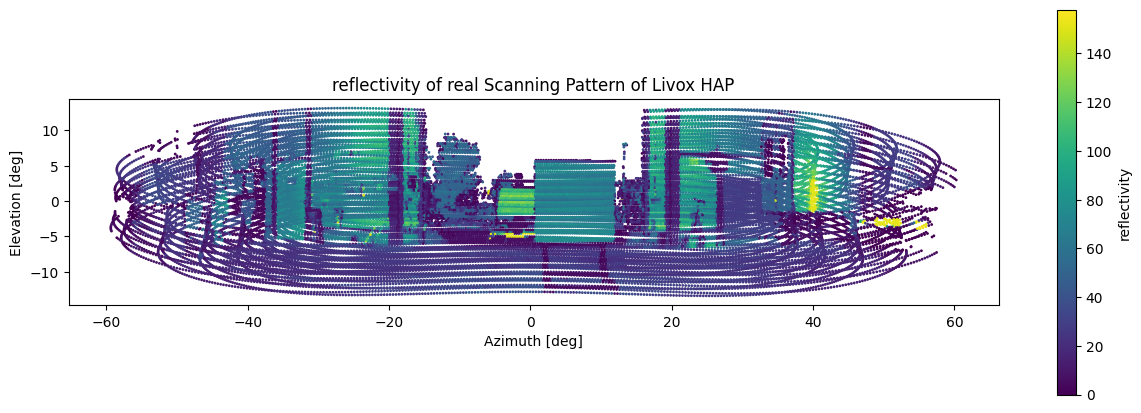

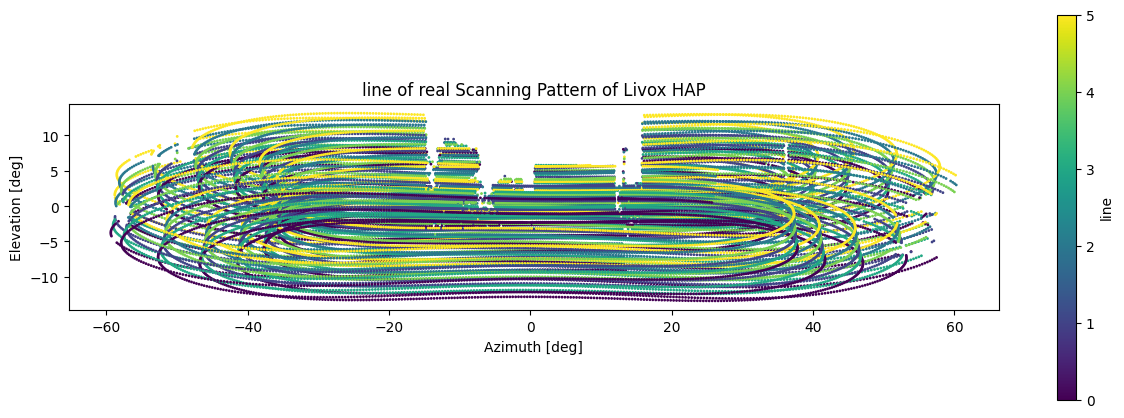

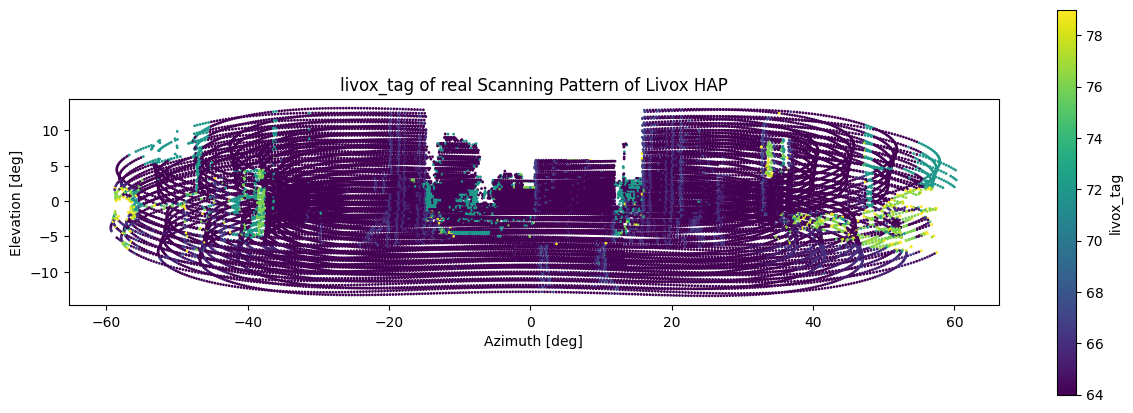

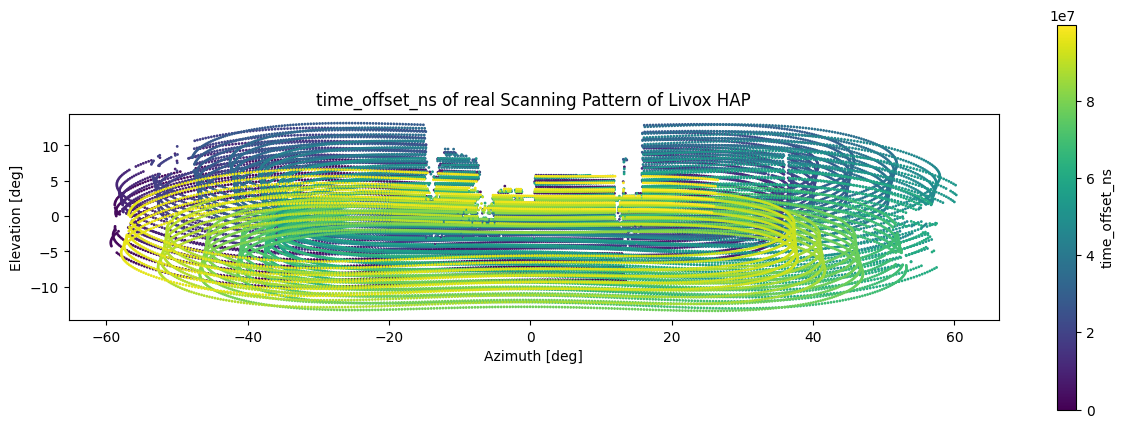

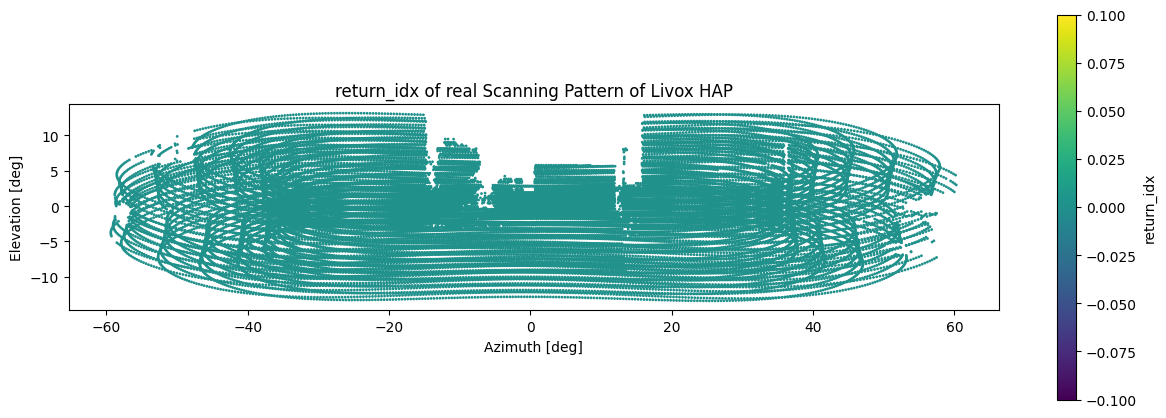

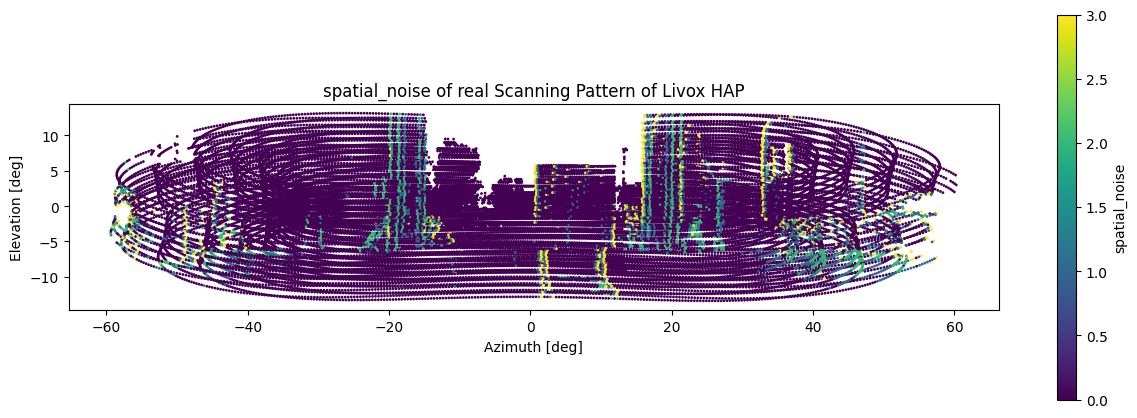

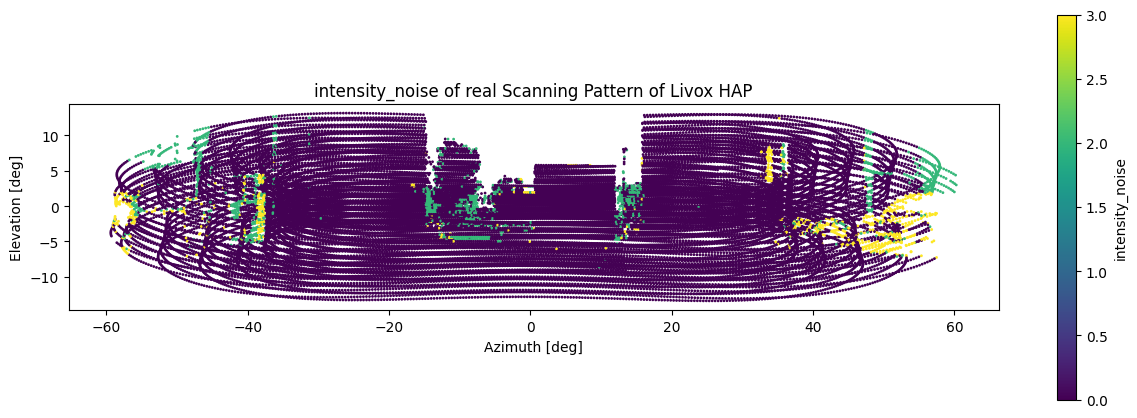

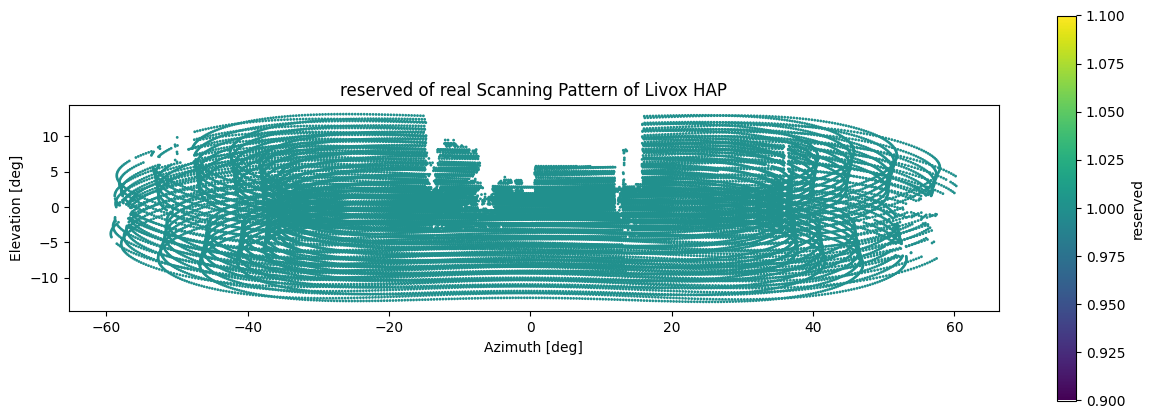

In [30]:
coloring = ["reflectivity", "line", "livox_tag" ,"time_offset_ns", "return_idx", "spatial_noise", "intensity_noise", "reserved"]
#coloring = ["livox_tag"]

# show only returns > 0
filtered_df = decoded_pc_df#[(decoded_pc_df["y"] > -1.2) & (decoded_pc_df["y"] <1.2)]
#filtered_df = filtered_df[(filtered_df["x"] > 0) & (decoded_pc_df["x"] <15)]
#filtered_df = filtered_df[(filtered_df["z"] > 0.5) & (decoded_pc_df["z"] <2)]

for color_idx,color in enumerate(coloring):
    plot_compensated_pc(filtered_df, coloring=color)
    #plot_3d_pc(filtered_df, coloring=color)
    #plot_interactive_3d_pc(filtered_df, coloring=color)
    #plot_with_open3d_pc(filtered_df, color)

# Analyse number of points in point cloud

In [17]:
def plot_histogram(array: np.array, title: str):
    """
    plots histograms for analysis of
    - how often UDP packet losses appear, like every n'th frame
    - how many points are lost in between frames
    """
    
    plt.hist(array, bins='auto')
    plt.title(f"{title}")
    #ax.set_xlabel("n frames")
    title = title.replace(" ", "_")
    filename = os.path.join(path,f'{title}.png')
    plt.savefig(filename)
    print(f"saving to {filename}")
    plt.show()
    plt.close()

1. Number of connections: 8
-------------------

2. The 8 Topic Names:
/tf_static
/tf
/livox/lidar
/initialpose
/clicked_point
/move_base_simple/goal
/parameter_events
/rosout
-------------------

4. Visualize Data:
saving to ./number_of_points_per_frame_(original_driver,_xfer_mode_0).png


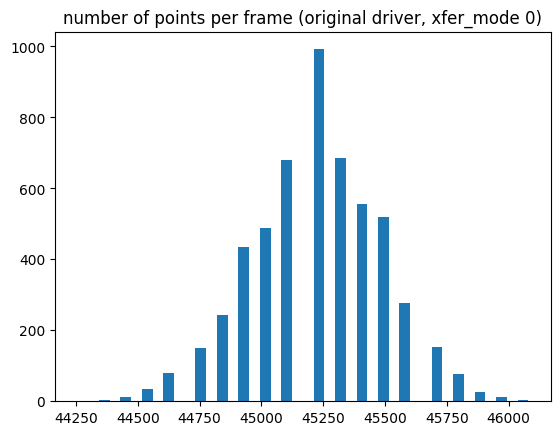

saving to ./(od)_Difference_from_45200_points_per_frame_in_multiples_of_UDP_packet_size_(96_points).png


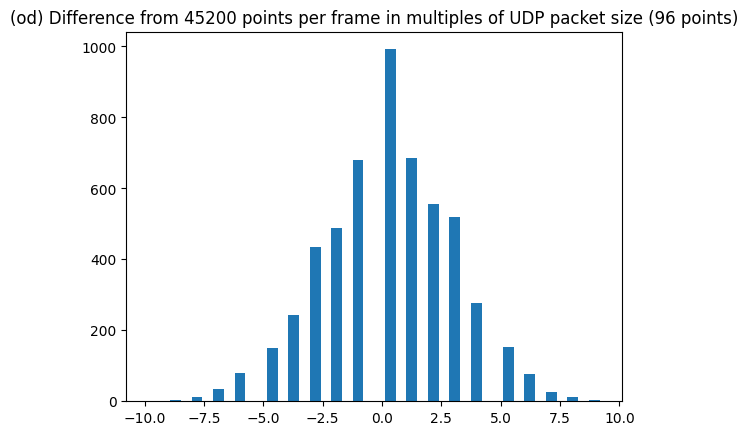

In [ ]:
with Reader(rosbag_dir) as ros2_reader:

    # get all connections
    ros2_conns = [conn for conn in ros2_reader.connections]
    print(f"1. Number of connections: {len(ros2_conns)}")
    print("-------------------\n")

    # print all topic names, to find out which topic we need to inspect
    print(f"2. The {len(ros2_conns)} Topic Names:")
    print(*[conn.topic for conn in ros2_conns], sep='\n')
    print("-------------------\n")

    print("4. Visualize Data:")
    # filter the connections for those topics that we are interested in
    pc_connections = filter_connections(ros2_conns, [topic])

    messages_of_conns = ros2_reader.messages(connections=pc_connections)

    n_points = []
    for m, msg in enumerate(messages_of_conns):
        (connection, timestamp, rawdata) = msg
        if connection.topic == topic:
            #print(f"   - Topic name: {connection.topic}") # topic
            #print(f"   - Message type name: {connection.msgtype}") # message type (massage type itself is a string)

            # deserialize data and print it
            data = typestore.deserialize_cdr(rawdata, connection.msgtype)
            #print(f"   - Number of points in pc according to header-width info: {data.width}")
            n_points.append(data.width)
    plot_histogram(n_points, "number of points per frame (altered driver, xfer_mode 0)")
    n_points = np.array(n_points)
    diff_n_points = (n_points - 45200)/96
    plot_histogram(diff_n_points, "(ad) Difference from 45200 points per frame in multiples of UDP packet size (96 points)")
    #print(diff_n_points)
    #mutiple_of_96 = diff_n_points % 96
    #print(mutiple_of_96)

# Analyse Timestamp offsets in a point cloud

1. Number of connections: 8
-------------------

2. The 8 Topic Names:
/clicked_point
/initialpose
/livox/lidar_192_168_43_117
/move_base_simple/goal
/parameter_events
/rosout
/tf
/tf_static
-------------------

4. Visualize Data:

   - Content of the PointFields array:
sensor_msgs__msg__PointField(name='x', offset=0, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='y', offset=4, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='z', offset=8, datatype=7, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __msgtype__='sensor_msgs/msg/PointField')
sensor_msgs__msg__PointField(name='time_offset', offset=12, datatype=6, count=1, INT8=1, UINT8=2, INT16=3, UINT16=4, INT32=5, UINT32=6, FLOAT32=7, FLOAT64=8, __ms

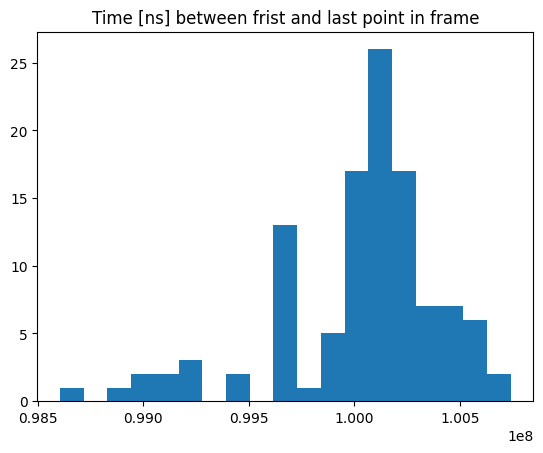

In [28]:
with Reader(rosbag_dir) as ros2_reader:

    # get all connections
    ros2_conns = [conn for conn in ros2_reader.connections]
    print(f"1. Number of connections: {len(ros2_conns)}")
    print("-------------------\n")

    # print all topic names, to find out which topic we need to inspect
    print(f"2. The {len(ros2_conns)} Topic Names:")
    print(*[conn.topic for conn in ros2_conns], sep='\n')
    print("-------------------\n")

    print("4. Visualize Data:")
    # filter the connections for those topics that we are interested in
    pc_connections = filter_connections(ros2_conns, [topic])

    messages_of_conns = ros2_reader.messages(connections=pc_connections)

    time_offset_within_frame = []
    for m, msg in enumerate(messages_of_conns):
        (connection, timestamp, rawdata) = msg
        if connection.topic == topic:
            #print(f"   - Topic name: {connection.topic}") # topic
            #print(f"   - Message type name: {connection.msgtype}") # message type (massage type itself is a string)

            # deserialize data and print it
            data = typestore.deserialize_cdr(rawdata, connection.msgtype)
            #print(f"   - Number of points in pc according to header-width info: {data.width}")

            # plot the point cloud in 2D
            decoded_pc_df = decode_compensated_pc(data, decode_bitmask=False)
            
            time_offset_within_frame.append(decoded_pc_df["time_offset_ns"].iloc[-1] - decoded_pc_df["time_offset_ns"].iloc[0])
    plot_histogram(time_offset_within_frame, title="Time [ns] between frist and last point in frame")

# Testing Area for Decoding

In [ ]:
lsb = np.array(37750032, dtype=np.uint32)
msb = np.array(147458, dtype=np.uint32)
print("input:")
print(f"lsb = {lsb}")
print(f"msb = {msb}")
print("\n###########\n")

''' MessageDataFormat_UserManual_p.pdf states on page 3: "the messages are serialized using little-endian encoding" '''

print("lsb")
ne_lsb = BitArray(uintne=lsb, length=32)  # native endian
le_lsb = BitArray(uintle=lsb, length=32)  # little endian
print(f"lsb little endian {le_lsb.uint}")
print(f"lsb little endian {le_lsb.bin}")
be_lsb = BitArray(uintbe=lsb, length=32)  # big endian
print(f"lsb big endian {be_lsb.uint}")
print(f"lsb big endian {be_lsb.bin}")

print("\n###########\n")

print("msb")
ne_msb = BitArray(uintne=msb, length=32)  # native endian
le_msb = BitArray(uintle=msb, length=32)  # little endian
print(f"msb little endian {le_msb.uint}")
print(f"msb little endian {le_msb.bin}")
be_msb = BitArray(uintbe=msb, length=32)  # big endian
print(f"msb big endian {be_msb.uint}")
print(f"msb big endian {be_msb.bin}")

## now we check the four possible interpretations:

print("\n##### interpretations ######\n" )

names = ["reserved", "line_idx", "beam_idx", "peak_idx", "face_idx", "point_type"]
bits = [8,8,4,2,4,6]

print("\n##### interpretations: lsb little endian ######\n" )
j = 0
for i in range(6):
    print(names[i], le_lsb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: lsb big endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], be_lsb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: msb little endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], le_msb[j:j+bits[i]].uint)
    j += bits[i]

print("\n##### interpretations: msb big endian ######\n" )
j = 0
j = 0
for i in range(6):
    print(names[i], be_msb[j:j+bits[i]].uint)
    j += bits[i]